# Ecommerce Customers — Complete Machine Learning Analysis

In [33]:
# Target variable : Yearly Amount Spent ($)
# Features used   : Avg. Session Length, Time on App,
#                   Time on Website, Length of Membership
# Models          : Linear Regression, Ridge, Lasso,
#                   Random Forest, Gradient Boosting
# Steps           : EDA → Preprocessing → Training → Evaluation →
#                   Feature Importance → Visualisation

# Libraries

In [34]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats


from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Dataset

In [39]:
df = pd.read_csv(r'/Users/festusattornelson/Documents/Projects/Python MSIT/CommerceML/Ecommerce Customers.csv')
df.head(2)

,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933


In [40]:
df.shape

(500, 8)

In [41]:
df.columns.tolist()

['Email',
 'Address',
 'Avatar',
 'Avg. Session Length',
 'Time on App',
 'Time on Website',
 'Length of Membership',
 'Yearly Amount Spent']

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    object 
 1   Address               500 non-null    object 
 2   Avatar                500 non-null    object 
 3   Avg. Session Length   500 non-null    float64
 4   Time on App           500 non-null    float64
 5   Time on Website       500 non-null    float64
 6   Length of Membership  500 non-null    float64
 7   Yearly Amount Spent   500 non-null    float64
dtypes: float64(5), object(3)
memory usage: 31.4+ KB


In [43]:
df.describe()

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,33.053194,12.052488,37.060445,3.533462,499.314038
std,0.992563,0.994216,1.010489,0.999278,79.314782
min,29.532429,8.508152,33.913847,0.269901,256.670582
25%,32.341822,11.388153,36.349257,2.930450,445.038277
50%,33.082008,11.983231,37.069367,3.533975,498.887875
75%,33.711985,12.753850,37.716432,4.126502,549.313828
max,36.139662,15.126994,40.005182,6.922689,765.518462


In [44]:
df.isna().sum()

Email                   0
Address                 0
Avatar                  0
Avg. Session Length     0
Time on App             0
Time on Website         0
Length of Membership    0
Yearly Amount Spent     0
dtype: int64

# Exploratory Data Analysis (EDA)

## Distribution of target variable

***Figure 1***

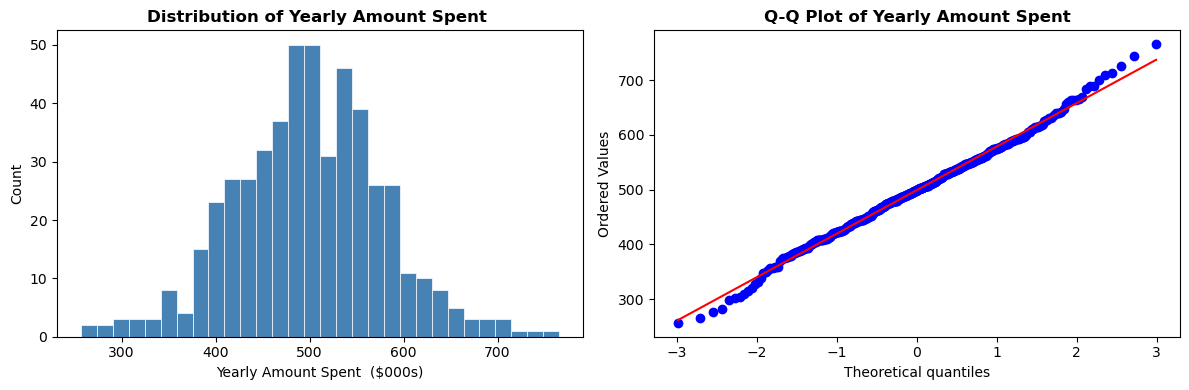

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
 
axes[0].hist(df['Yearly Amount Spent'], bins=30, color='steelblue', edgecolor='white', linewidth=0.5)
axes[0].set_title('Distribution of Yearly Amount Spent ', fontweight='bold')
axes[0].set_xlabel('Yearly Amount Spent  ($000s)')
axes[0].set_ylabel('Count')
 
# Q-Q style: sorted Yearly Amount Spent vs normal quantiles
from scipy import stats
stats.probplot(df['Yearly Amount Spent'], plot=axes[1])
axes[1].set_title('Q-Q Plot of Yearly Amount Spent', fontweight='bold')
 
plt.tight_layout()
plt.savefig('01_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## Distribution of all features + target

***Figure 2***

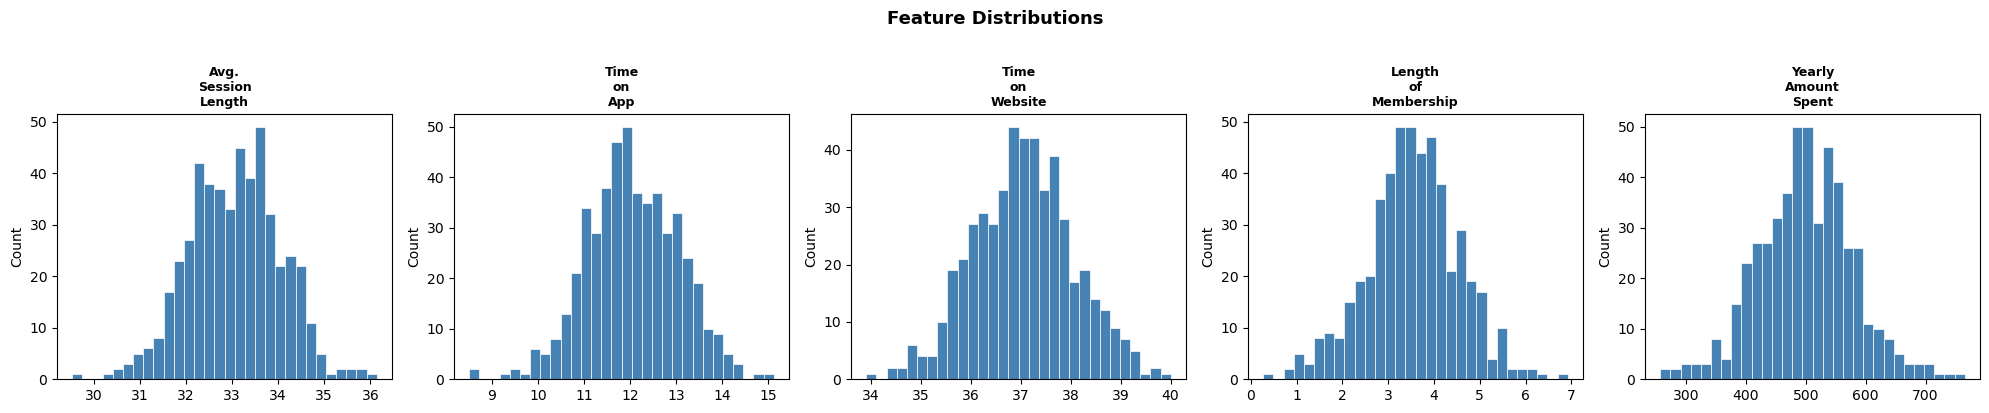


Saved: 02_numeric_features_distributions.png


In [47]:
features = ['Avg. Session Length', 'Time on App', 'Time on Website', 'Length of Membership']

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
 
for ax, col in zip(axes, features + ['Yearly Amount Spent']):
    ax.hist(df[col], bins=30, color='steelblue', edgecolor='white', linewidth=0.5)
    ax.set_title(col.replace(' ', '\n'), fontweight='bold', fontsize=9)
    ax.set_ylabel('Count')
 
plt.suptitle('Feature Distributions', fontweight='bold', y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig('02_numeric_features_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nSaved: 02_numeric_features_distributions.png")

## Pairplot — relationships among all variables

***Figure 3***

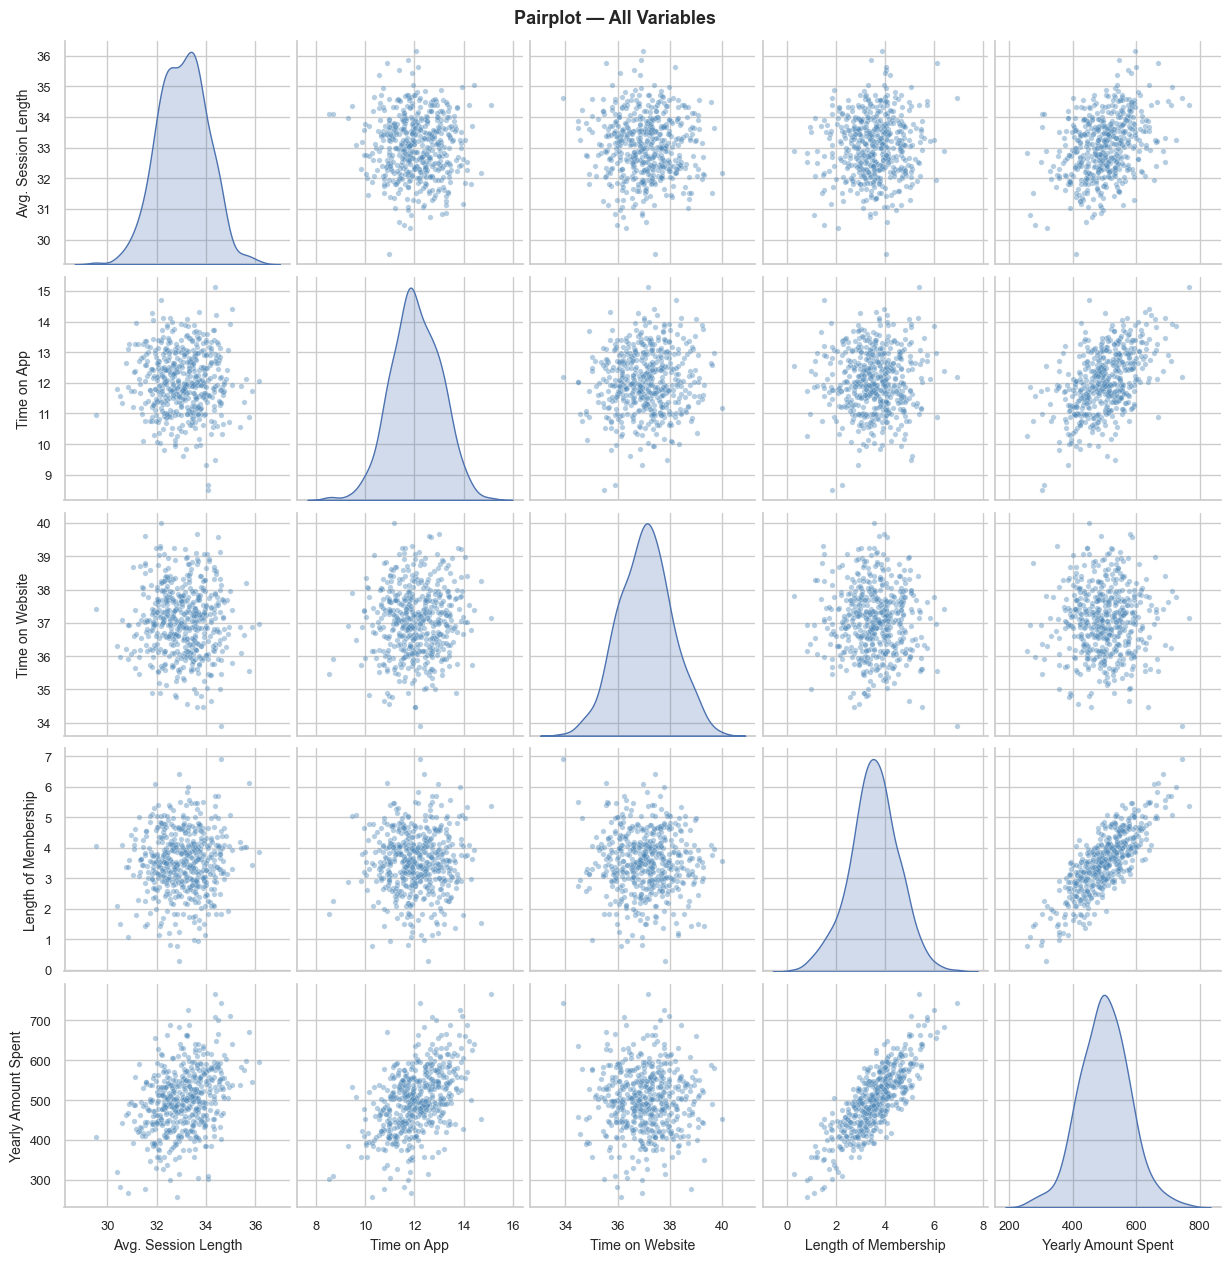

Saved: 03_pairplot.png


In [48]:
sns.set(style='whitegrid', font_scale=0.85)
pair = sns.pairplot(df, diag_kind='kde', plot_kws={'alpha': 0.4, 's': 15, 'color': 'steelblue'})
pair.fig.suptitle('Pairplot — All Variables', y=1.01, fontweight='bold', fontsize=13)
plt.savefig('03_pairplot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 03_pairplot.png")

## Correlation heatmap

***Figure 4***

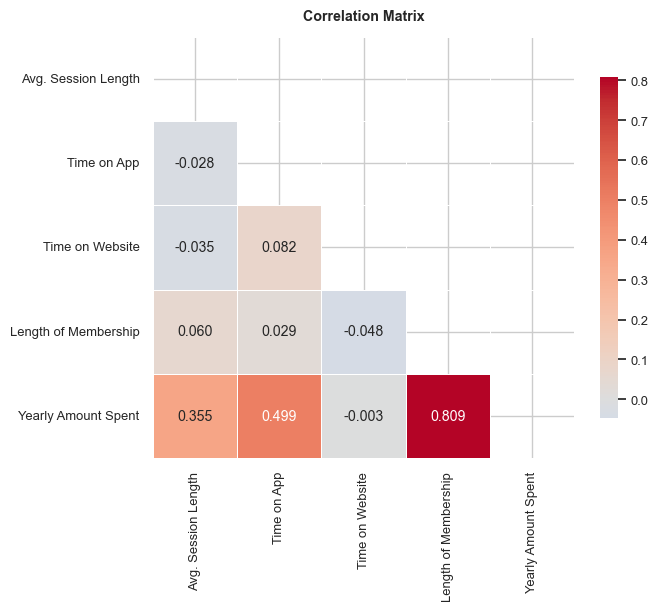

Saved: 04_correlation_heatmap.png


In [53]:
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(7, 6))
mask = np.triu(np.ones_like(numeric_df.corr(), dtype=bool))
sns.heatmap(numeric_df.corr(), mask=mask, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix', fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('04_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 04_correlation_heatmap.png")

## Scatter plots of each feature vs target

***Figure 5***

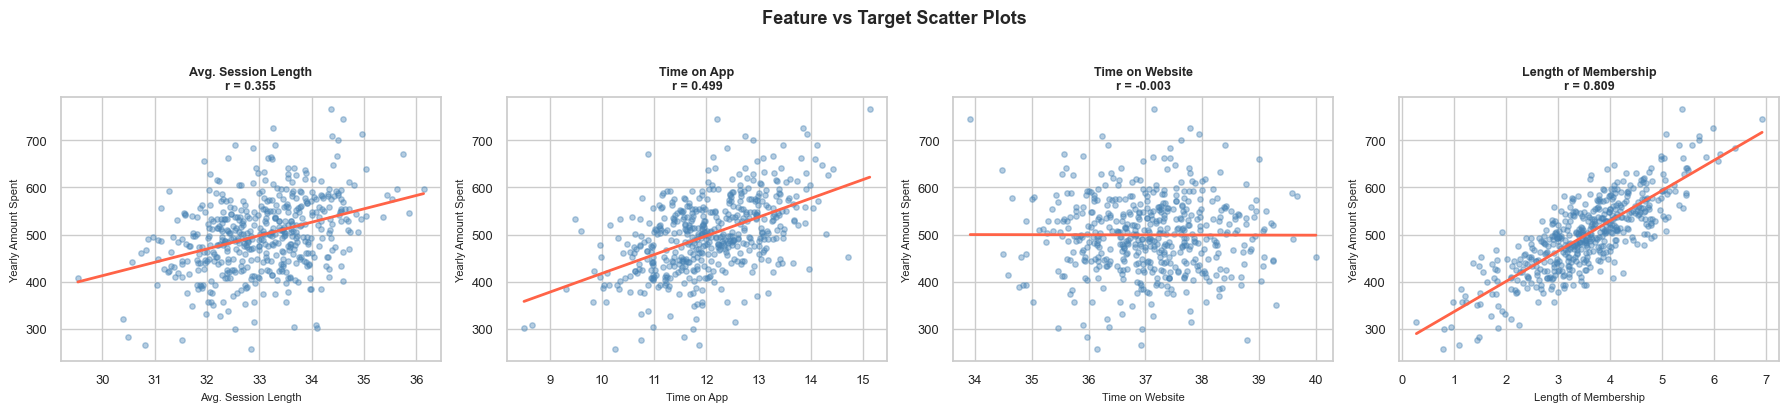

Saved: 05_scatter_plots.png


In [74]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
 
for ax, feat in zip(axes, features):
    ax.scatter(df[feat], df['Yearly Amount Spent'],
               alpha=0.4, s=15, color='steelblue')
    m, b = np.polyfit(df[feat], df['Yearly Amount Spent'], 1)
    x_line = np.linspace(df[feat].min(), df[feat].max(), 200)
    ax.plot(x_line, m * x_line + b, color='tomato', linewidth=2)
    r_val = df[feat].corr(df['Yearly Amount Spent'])
    ax.set_title(f'{feat}\nr = {r_val:.3f}', fontweight='bold', fontsize=9)
    ax.set_xlabel(feat, fontsize=8)
    ax.set_ylabel('Yearly Amount Spent', fontsize=8)
 
plt.suptitle('Feature vs Target Scatter Plots', fontweight='bold', y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig('05_scatter_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 05_scatter_plots.png")

# Preprocessing

In [61]:
X = numeric_df.drop('Yearly Amount Spent', axis=1)
y = df['Yearly Amount Spent']

***Train / test split (80 / 20)***

In [62]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

***Scale features — fit ONLY on training data to prevent leakage***

In [63]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

In [64]:
print(f"\nTrain size : {X_train.shape[0]} samples")
print(f"Test size  : {X_test.shape[0]} samples")


Train size : 400 samples
Test size  : 100 samples


# Model Training and Evaluation

In [65]:
models = {
    'Linear Regression' : LinearRegression(),
    'Ridge'             : Ridge(alpha=1.0),
    'Lasso'             : Lasso(alpha=0.1),
    'Random Forest'     : RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting' : GradientBoostingRegressor(n_estimators=100, random_state=42),
}

In [70]:
results  = {}
kf       = KFold(n_splits=5, shuffle=True, random_state=42)
 
for name, model in models.items():
    model.fit(X_train_sc, y_train)
    y_pred = model.predict(X_test_sc)
 
    r2   = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    cv   = cross_val_score(model, X_train_sc, y_train, cv=kf, scoring='r2')
 
    results[name] = {
        'R2'         : round(r2, 4),
        'RMSE'       : round(rmse, 4),
        'MAE'        : round(mae, 4),
        'CV_R2_mean' : round(cv.mean(), 4),
        'CV_R2_std'  : round(cv.std(), 4),
        'y_pred'     : y_pred,
    }
 
    #print(f"\n{name}")
    #print(f"  R²            : {r2:.4f}")
    #print(f"  RMSE          : {rmse:.4f}")
    #print(f"  MAE           : {mae:.4f}")
    #print(f"  CV R² (5-fold): {cv.mean():.4f} ± {cv.std():.4f}")
 


In [71]:
# Print summary table
results_df = pd.DataFrame({
    k: {m: v for m, v in r.items() if m != 'y_pred'}
    for k, r in results.items()
}).T
print("\n--- Summary Table ---")
print(results_df.to_string())


--- Summary Table ---
                       R2     RMSE      MAE  CV_R2_mean  CV_R2_std
Linear Regression  0.9778  10.4816   8.5584      0.9848     0.0026
Ridge              0.9779  10.4609   8.5385      0.9848     0.0027
Lasso              0.9778  10.4770   8.5526      0.9848     0.0026
Random Forest      0.9336  18.1366  13.6254      0.9381     0.0145
Gradient Boosting  0.9563  14.7070  11.7899      0.9549     0.0094


# Model Comparisons 

In [72]:
model_names = list(results.keys())
short_names  = ['Linear\nReg.', 'Ridge', 'Lasso', 'Random\nForest', 'Grad.\nBoosting']
r2_vals      = [results[m]['R2']         for m in model_names]
rmse_vals    = [results[m]['RMSE']       for m in model_names]
cv_means     = [results[m]['CV_R2_mean'] for m in model_names]
cv_stds      = [results[m]['CV_R2_std']  for m in model_names]
 
colors = ['#2166AC', '#2166AC', '#2166AC', '#43A047', '#E53935']

## R² and RMSE side-by-side

***Figure 6***

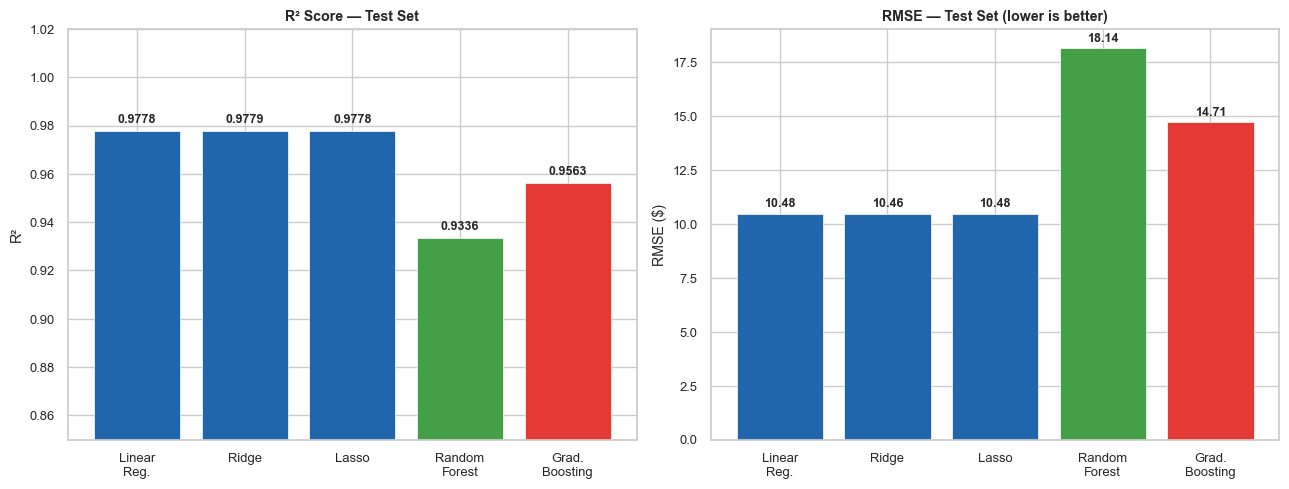

Saved: 06_model_comparison.png


In [75]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
 
bars1 = axes[0].bar(short_names, r2_vals, color=colors, edgecolor='white', linewidth=0.5)
axes[0].set_title('R² Score — Test Set', fontweight='bold')
axes[0].set_ylabel('R²')
axes[0].set_ylim(0.85, 1.02)
for bar, val in zip(bars1, r2_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
 
bars2 = axes[1].bar(short_names, rmse_vals, color=colors, edgecolor='white', linewidth=0.5)
axes[1].set_title('RMSE — Test Set (lower is better)', fontweight='bold')
axes[1].set_ylabel('RMSE ($)')
for bar, val in zip(bars2, rmse_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f'{val:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
 
plt.tight_layout()
plt.savefig('06_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 06_model_comparison.png")

## Cross-validation R² with error bars

***Figure 7***

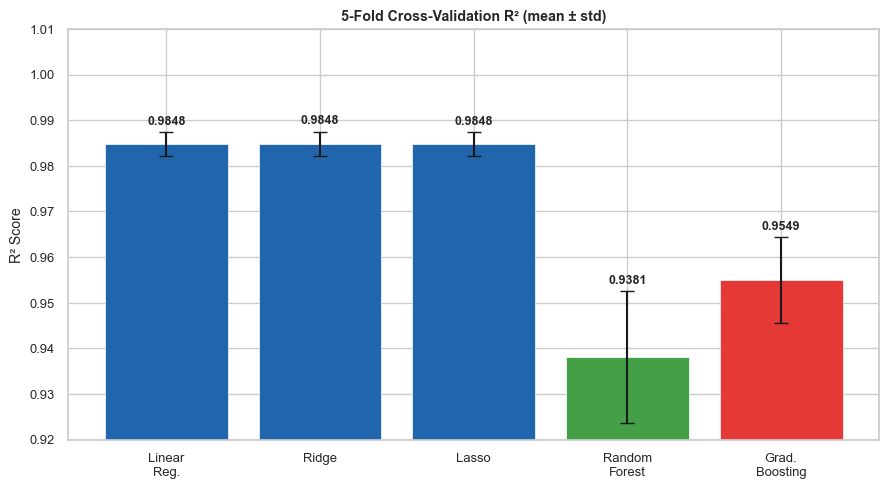

Saved: 07_cross_validation.png


In [76]:
plt.figure(figsize=(9, 5))
x_pos = np.arange(len(model_names))
plt.bar(x_pos, cv_means, yerr=cv_stds, capsize=5, color=colors,
        edgecolor='white', linewidth=0.5, error_kw={'linewidth': 1.5})
plt.xticks(x_pos, short_names)
plt.ylabel('R² Score')
plt.title('5-Fold Cross-Validation R² (mean ± std)', fontweight='bold')
plt.ylim(0.92, 1.01)
for i, (m, s) in enumerate(zip(cv_means, cv_stds)):
    plt.text(i, m + s + 0.001, f'{m:.4f}', ha='center', va='bottom',
             fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig('07_cross_validation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 07_cross_validation.png")

# Actual vs Predicted Plots

***Figure 8***

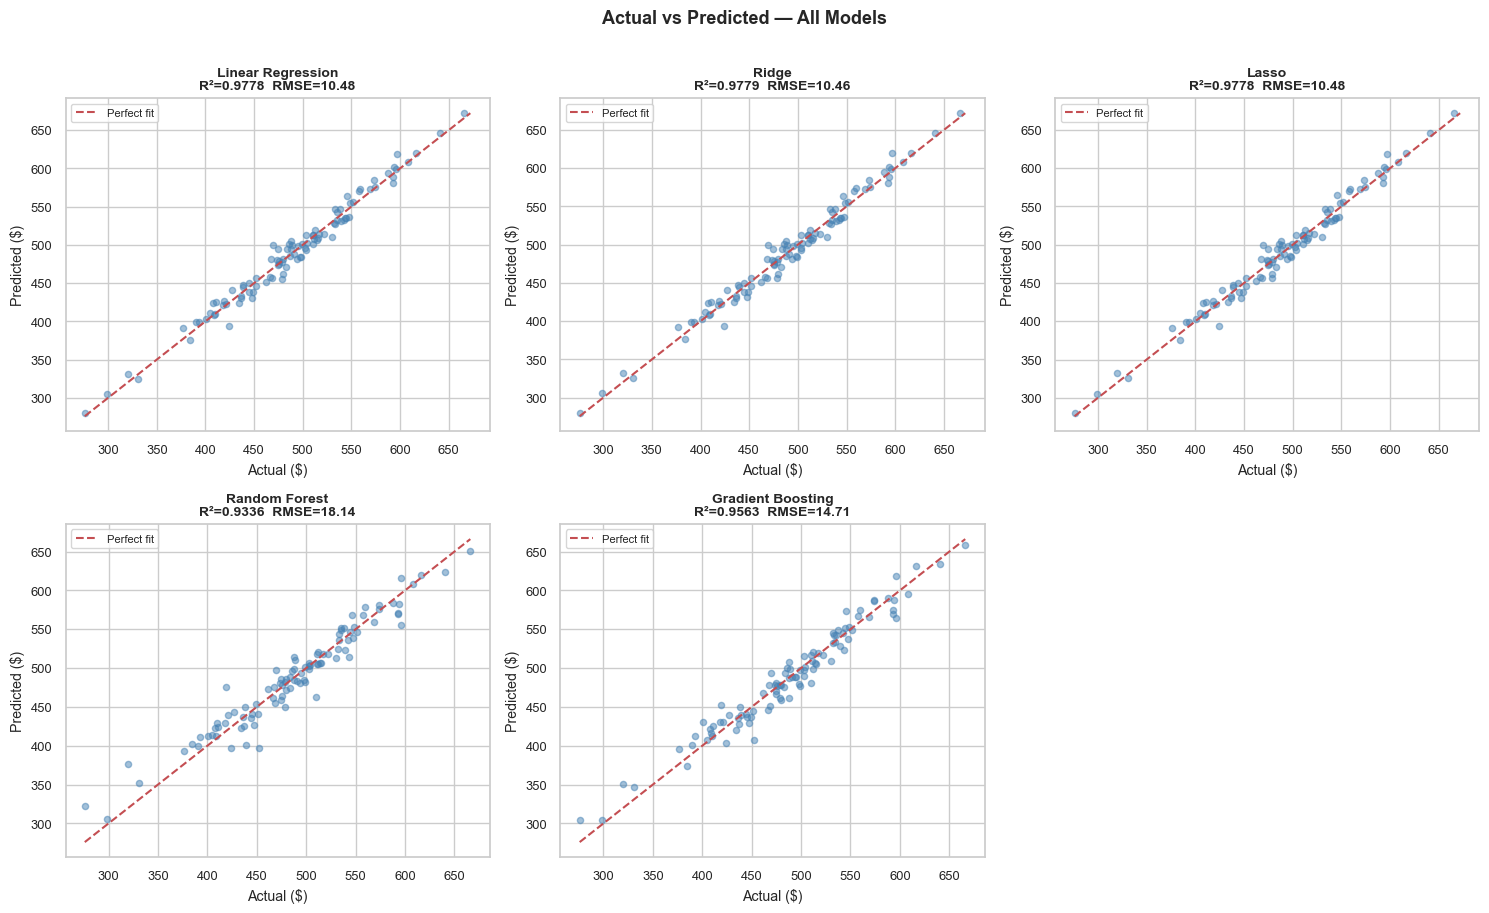

Saved: 08_actual_vs_predicted.png


In [77]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()
 
for i, (name, res) in enumerate(results.items()):
    ax = axes[i]
    ax.scatter(y_test, res['y_pred'], alpha=0.5, s=20, color='steelblue')
    mn = min(y_test.min(), res['y_pred'].min())
    mx = max(y_test.max(), res['y_pred'].max())
    ax.plot([mn, mx], [mn, mx], 'r--', linewidth=1.5, label='Perfect fit')
    ax.set_title(f"{name}\nR²={res['R2']:.4f}  RMSE={res['RMSE']:.2f}",
                 fontweight='bold', fontsize=10)
    ax.set_xlabel('Actual ($)')
    ax.set_ylabel('Predicted ($)')
    ax.legend(fontsize=8)
 
axes[-1].axis('off')
plt.suptitle('Actual vs Predicted — All Models', fontweight='bold', y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig('08_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 08_actual_vs_predicted.png")

# Linear Regression Coefficients

***Figure 9***


--- Linear Regression Coefficients (scaled) ---
             Feature  Coefficient
     Time on Website     0.315469
 Avg. Session Length    25.250381
         Time on App    38.703501
Length of Membership    63.543211


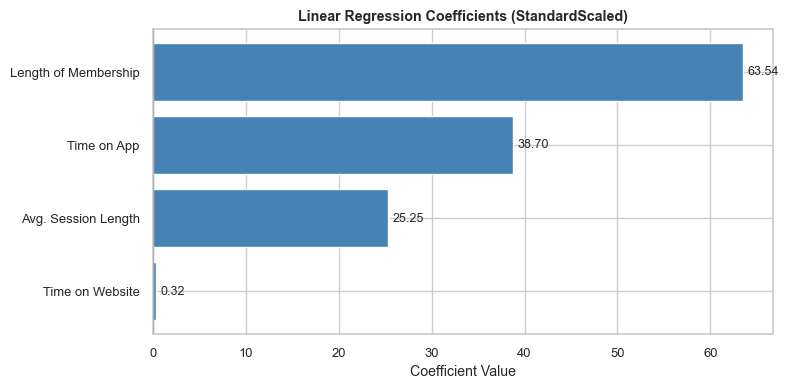

Saved: 09_lr_coefficients.png


In [78]:
lr_model = models['Linear Regression']
coeff_df = pd.DataFrame({
    'Feature'    : features,
    'Coefficient': lr_model.coef_
}).sort_values('Coefficient', ascending=True)
 
print("\n--- Linear Regression Coefficients (scaled) ---")
print(coeff_df.to_string(index=False))
 
plt.figure(figsize=(8, 4))
colors_coeff = ['tomato' if c < 0 else 'steelblue' for c in coeff_df['Coefficient']]
plt.barh(coeff_df['Feature'], coeff_df['Coefficient'], color=colors_coeff, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Linear Regression Coefficients (StandardScaled)', fontweight='bold')
plt.xlabel('Coefficient Value')
for i, (feat, val) in enumerate(zip(coeff_df['Feature'], coeff_df['Coefficient'])):
    plt.text(val + (0.5 if val >= 0 else -0.5), i,
             f'{val:.2f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)
plt.tight_layout()
plt.savefig('09_lr_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 09_lr_coefficients.png")

# Feature Importance - Tree Models

***Figure 10***

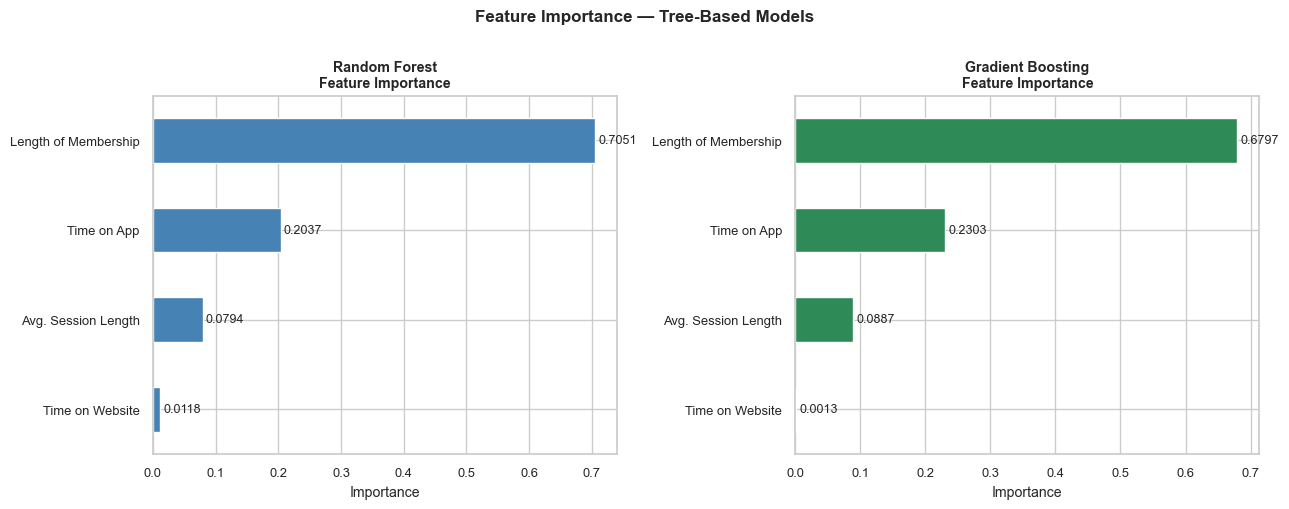

Saved: 10_feature_importance.png


In [79]:
rf_model = models['Random Forest']
gb_model = models['Gradient Boosting']
 
fi_rf = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=True)
fi_gb = pd.Series(gb_model.feature_importances_, index=features).sort_values(ascending=True)
 
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
 
fi_rf.plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Random Forest\nFeature Importance', fontweight='bold')
axes[0].set_xlabel('Importance')
for i, v in enumerate(fi_rf):
    axes[0].text(v + 0.005, i, f'{v:.4f}', va='center', fontsize=9)
 
fi_gb.plot(kind='barh', ax=axes[1], color='seagreen', edgecolor='white')
axes[1].set_title('Gradient Boosting\nFeature Importance', fontweight='bold')
axes[1].set_xlabel('Importance')
for i, v in enumerate(fi_gb):
    axes[1].text(v + 0.005, i, f'{v:.4f}', va='center', fontsize=9)
 
plt.suptitle('Feature Importance — Tree-Based Models', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('10_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 10_feature_importance.png")

# Residual Analysis - Best model (Linear regression)

***Figure 11***

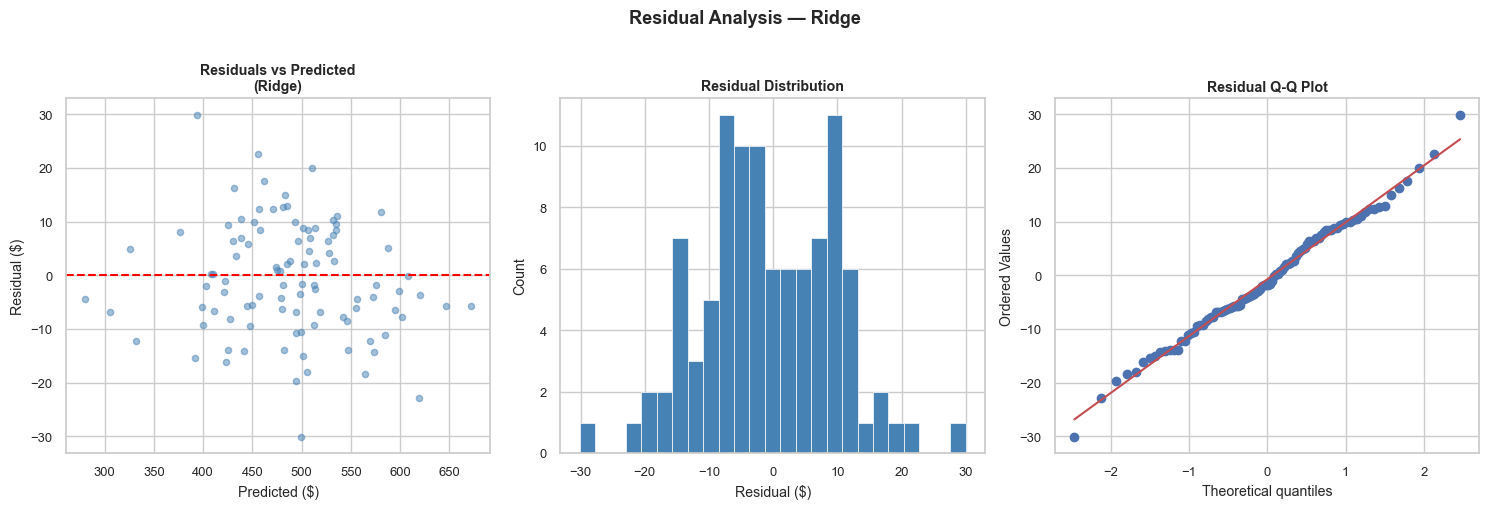

Saved: 11_residual_analysis.png


In [80]:
best_name = max(results, key=lambda m: results[m]['R2'])
best_pred = results[best_name]['y_pred']
residuals  = y_test - best_pred
 
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
 
# Residuals vs Predicted
axes[0].scatter(best_pred, residuals, alpha=0.5, s=20, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_title(f'Residuals vs Predicted\n({best_name})', fontweight='bold')
axes[0].set_xlabel('Predicted ($)')
axes[0].set_ylabel('Residual ($)')
 
# Residual distribution
axes[1].hist(residuals, bins=25, color='steelblue', edgecolor='white', linewidth=0.5)
axes[1].set_title('Residual Distribution', fontweight='bold')
axes[1].set_xlabel('Residual ($)')
axes[1].set_ylabel('Count')
 
# Q-Q plot of residuals
stats.probplot(residuals, plot=axes[2])
axes[2].set_title('Residual Q-Q Plot', fontweight='bold')
 
plt.suptitle(f'Residual Analysis — {best_name}', fontweight='bold', y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig('11_residual_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 11_residual_analysis.png")

# Final Summary

In [82]:
 best = results[best_name]
print("\n" + "=" * 60)
print("FINAL SUMMARY")
print("=" * 60)
print(f"Dataset         : 500 customers, 4 numeric features")
print(f"Target          : Yearly Amount Spent ($)")
print(f"Best model      : {best_name}")
print(f"  R²            : {best['R2']}")
print(f"  RMSE          : ${best['RMSE']:.2f}")
print(f"  MAE           : ${best['MAE']:.2f}")
print(f"  CV R²         : {best['CV_R2_mean']} ± {best['CV_R2_std']}")
print(f"\nTop predictor   : Length of Membership (r = 0.809)")
print(f"Weakest feature : Time on Website (r = -0.003)")
print(f"\nOutputs         : 11 PNG plots saved to working directory")
print("=" * 60)


FINAL SUMMARY
Dataset         : 500 customers, 4 numeric features
Target          : Yearly Amount Spent ($)
Best model      : Ridge
  R²            : 0.9779
  RMSE          : $10.46
  MAE           : $8.54
  CV R²         : 0.9848 ± 0.0027

Top predictor   : Length of Membership (r = 0.809)
Weakest feature : Time on Website (r = -0.003)

Outputs         : 11 PNG plots saved to working directory
